# 论文实验图表

本 notebook 生成论文实验部分的所有图表，包括：
1. **Fig.1**: 动态场景方法对比（N=10, 4个速度）
2. **Fig.2**: 性能-计算权衡散点图
3. **Fig.3**: 规模扩展对比（N=10→50）
4. **Fig.4**: BC训练曲线（accuracy & eval P_int）
5. **Fig.5**: 消融实验（观测设计）
6. **Fig.6**: Zero-shot跨规模泛化
7. **Fig.7**: 失败分析（干扰源距离/频率差分布）

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_DIR = '../results_data'
FIG_DIR = 'figures'
import os
%matplotlib inline
os.makedirs(FIG_DIR, exist_ok=True)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def gs(dyn, speed, field):
    """从动态结果按速度取值，兼容 speed_X / speed_X.0 两种键；缺失返回 np.nan。"""
    if not isinstance(dyn, dict) or 'results' not in dyn:
        return np.nan
    res = dyn['results']
    for k in (f'speed_{speed}', f'speed_{speed}.0', f'speed_{int(speed)}'):
        if k in res:
            return res[k].get(field, np.nan)
    return np.nan

print('Data files available:')
for f in sorted(os.listdir(DATA_DIR)):
    print(f'  {f}')

Data files available:
  bc_orthogonal_N10_stats.json
  bc_orthogonal_N20_stats.json
  bc_orthogonal_N30_stats.json
  bc_orthogonal_N50_stats.json
  centralized_bc_N10_stats.json
  centralized_bc_N20_stats.json
  centralized_bc_N30_stats.json
  centralized_interval_sweep.json
  dist_N10_speed0.json
  dist_N10_speed10.json
  dist_N10_speed20.json
  dist_N10_speed30.json
  dist_N10_speed40.json
  dist_N20_speed0.json
  dist_N20_speed10.json
  dist_N20_speed20.json
  dist_N20_speed30.json
  dist_N20_speed40.json
  dist_N30_speed0.json
  dist_N30_speed10.json
  dist_N30_speed20.json
  dist_N30_speed30.json
  dist_N30_speed40.json
  dist_N50_speed0.json
  dist_N50_speed10.json
  dist_N50_speed20.json
  dist_N50_speed30.json
  dist_N50_speed40.json
  dynamic_750
  dynamic_bc_bc_dynamic_s10_N10.json
  dynamic_bc_bc_dynamic_s10_N20.json
  dynamic_bc_bc_orthogonal_N10.json
  dynamic_bc_bc_orthogonal_N20.json
  dynamic_bc_bc_orthogonal_N30.json
  dynamic_bc_bc_orthogonal_N50.json
  dynamic_carlto

## Fig.1: 动态场景方法对比 (N=10, 4个速度)

柱状图展示所有方法在不同移动速度下的累积互扰概率。

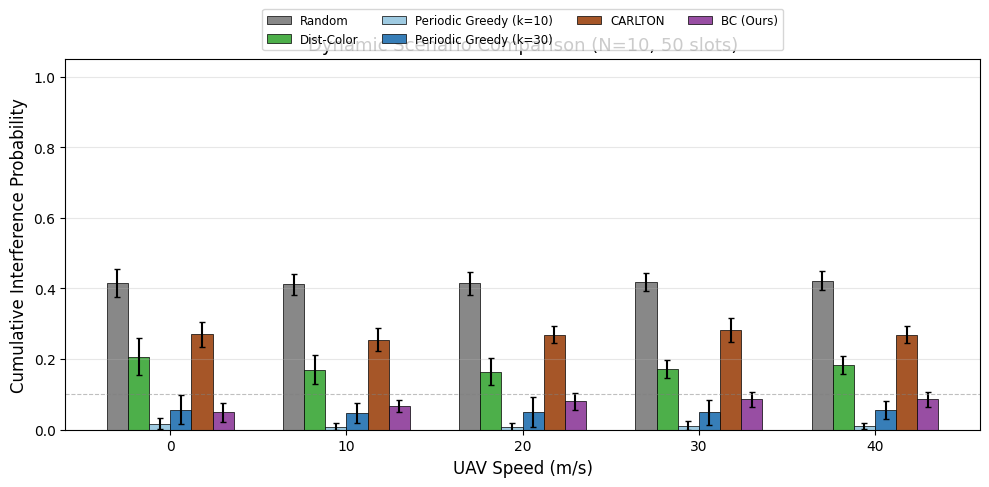

In [2]:
# 加载N=10分布式基线结果
speeds = [0, 10, 20, 30, 40]
methods_order = ['random', 'dist_coloring', 'periodic_greedy_k10', 'periodic_greedy']
method_labels = {
    'random': 'Random',
    'dist_coloring': 'Dist-Color',
    'periodic_greedy_k10': 'Periodic Greedy (k=10)',
    'periodic_greedy': 'Periodic Greedy (k=30)',
}
method_colors = {
    'random': '#888888',
    'dist_coloring': '#4daf4a',
    'periodic_greedy_k10': '#9ecae1',
    'periodic_greedy': '#377eb8',
}

# 收集基线数据
baseline_data = {}
for speed in speeds:
    data = load_json(f'{DATA_DIR}/dist_N10_speed{speed}.json')
    for s in data['summary']:
        m = s['method']
        if m not in baseline_data:
            baseline_data[m] = {'probs': [], 'stds': [], 'times': []}
        baseline_data[m]['probs'].append(s['cum_interf_prob'])
        baseline_data[m]['stds'].append(s['std'])
        baseline_data[m]['times'].append(s['avg_time_s'])

# 集中式周期贪心（长重规划间隔 k=30，需全局CSI，体现集中式计算代价）
cg = load_json(f'{DATA_DIR}/centralized_interval_sweep.json')
for REPLAN_K, key in [(30, 'periodic_greedy'), (10, 'periodic_greedy_k10')]:
    periodic = {'probs': [], 'stds': []}
    for speed in speeds:
        sp = cg['10'][str(speed)][str(REPLAN_K)]
        periodic['probs'].append(sp['p_int'])
        periodic['stds'].append(sp['std'])
    baseline_data[key] = periodic

# 加载BC动态结果
bc_dyn = load_json(f'{DATA_DIR}/dynamic_bc_bc_orthogonal_N10.json')
bc_probs = []
bc_stds = []
for speed in speeds:
    bc_probs.append(gs(bc_dyn, speed, 'cum_interf_prob_mean'))
    bc_stds.append(gs(bc_dyn, speed, 'cum_interf_prob_std'))

# 加载CARLTON动态结果（CTDE value-based RL 基线，Cohen et al. 2024）
carlton_dyn = load_json(f'{DATA_DIR}/dynamic_carlton_N10.json')
carlton_probs = []
carlton_stds = []
for speed in speeds:
    carlton_probs.append(gs(carlton_dyn, speed, 'cum_interf_prob_mean'))
    carlton_stds.append(gs(carlton_dyn, speed, 'cum_interf_prob_std'))

# 画图
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(speeds))
width = 0.12

all_methods = methods_order + ['carlton', 'bc']
all_labels = [method_labels[m] for m in methods_order] + ['CARLTON', 'BC (Ours)']
all_colors = [method_colors[m] for m in methods_order] + ['#a65628', '#984ea3']
all_probs = [baseline_data[m]['probs'] for m in methods_order] + [carlton_probs, bc_probs]
all_stds = [baseline_data[m]['stds'] for m in methods_order] + [carlton_stds, bc_stds]

for i, (label, color, probs, stds) in enumerate(zip(all_labels, all_colors, all_probs, all_stds)):
    offset = (i - len(all_methods)/2 + 0.5) * width
    bars = ax.bar(x + offset, probs, width, label=label, color=color, yerr=stds, capsize=2, edgecolor='black', linewidth=0.5)

ax.set_xlabel('UAV Speed (m/s)', fontsize=12)
ax.set_ylabel('Cumulative Interference Probability', fontsize=12)
ax.set_title('Dynamic Scenario Comparison (N=10, 50 slots)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in speeds])
ax.legend(ncol=4, fontsize=8.5, loc='upper center', bbox_to_anchor=(0.5, 1.15))
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
plt.tight_layout()
plt.show()


## Fig.2: 性能-计算权衡散点图

X轴: 推理时间(对数), Y轴: 互扰概率。展示BC在Pareto前沿。

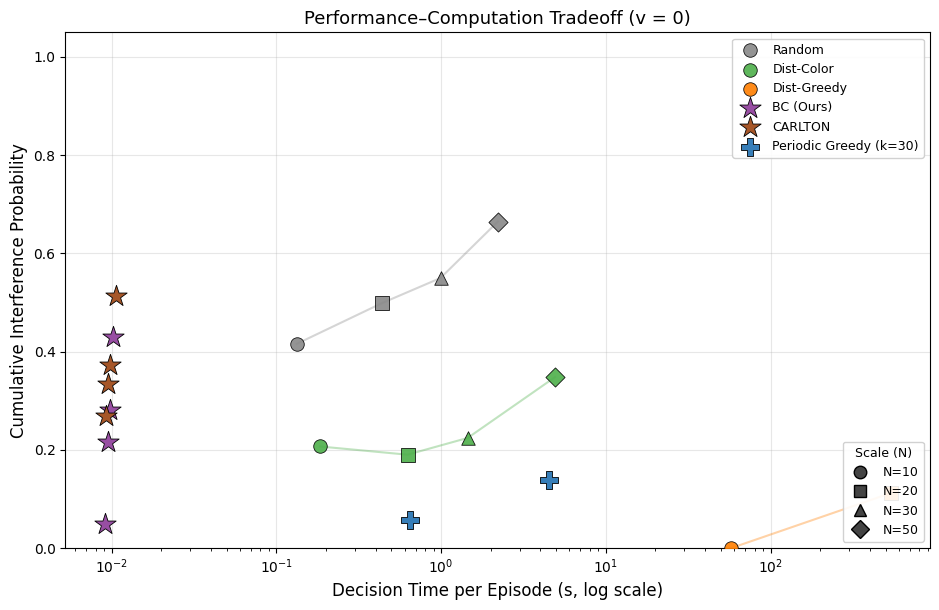

In [3]:
# Fig.2: 性能-计算权衡散点图（P_int vs 决策时间，单图，合并原两子图）
sizes = [10, 20, 30, 50]
methods = ['random', 'dist_coloring', 'dist_greedy']
method_colors = {'random': '#888888', 'dist_coloring': '#4daf4a', 'dist_greedy': '#ff7f00'}
method_labels = {'random': 'Random', 'dist_coloring': 'Dist-Color', 'dist_greedy': 'Dist-Greedy'}
markers = {10: 'o', 20: 's', 30: '^', 50: 'D'}

fig, ax = plt.subplots(figsize=(9.5, 6.2))

# baseline: 方法=颜色, N=形状; 同方法按决策时间串成 trade-off 曲线
seen_method = set()
for m in methods:
    pts = []
    for n in sizes:
        df = f'{DATA_DIR}/dist_N{n}_speed0.json'
        if os.path.exists(df):
            d = load_json(df)
            sm = {s['method']: s for s in d['summary']}
            if m in sm:
                pts.append((sm[m]['avg_time_s'], sm[m]['cum_interf_prob'], n))
    if not pts:
        continue
    pts.sort(key=lambda x: x[0])
    xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
    ax.plot(xs, ys, color=method_colors[m], alpha=0.35, linewidth=1.5, zorder=2)
    for t, p, n in pts:
        lab = method_labels[m] if m not in seen_method else None
        seen_method.add(m)
        ax.scatter(t, p, c=method_colors[m], marker=markers[n], s=95, label=lab,
                   alpha=0.9, edgecolors='k', linewidths=0.6, zorder=3)

# BC / CARLTON 彩色星号点（Pareto 前沿）
for key, col, lab in [('bc', '#984ea3', 'BC (Ours)'), ('carlton', '#a65628', 'CARLTON')]:
    xs, ys = [], []
    for n in sizes:
        if key == 'bc':
            bc = load_json(f'{DATA_DIR}/dynamic_bc_bc_orthogonal_N{n}.json')
            t = gs(bc, 0, 'avg_total_inference_time_s'); p = gs(bc, 0, 'cum_interf_prob_mean')
        else:
            cf = f'{DATA_DIR}/dynamic_carlton_N{n}.json'
            if os.path.exists(cf):
                ca = load_json(cf)
                t = gs(ca, 0, 'avg_total_inference_time_s'); p = gs(ca, 0, 'cum_interf_prob_mean')
            else:
                t, p = np.nan, np.nan
        if not np.isnan(t) and not np.isnan(p):
            xs.append(t); ys.append(p)
    if xs:
        ax.scatter(xs, ys, c=col, marker='*', s=260, label=lab, edgecolors='k', linewidths=0.6, zorder=5)

# 集中式周期贪心（k=30）作为集中式参照点（仅 N=10,20 有扫描数据；x=整幕重规划耗时）
cg = load_json(f'{DATA_DIR}/centralized_interval_sweep.json')
pg_x, pg_y = [], []
for n in [10, 20]:
    sp = cg[str(n)]['0']['30']
    pg_x.append(sp['time_s']); pg_y.append(sp['p_int'])
if pg_x:
    ax.scatter(pg_x, pg_y, c='#377eb8', marker='P', s=150, label='Periodic Greedy (k=30)', edgecolors='k', linewidths=0.6, zorder=4)

ax.set_xscale('log')
ax.set_xlabel('Decision Time per Episode (s, log scale)', fontsize=12)
ax.set_ylabel('Cumulative Interference Probability', fontsize=12)
ax.set_title('Performance\u2013Computation Tradeoff (v = 0)', fontsize=13)
from matplotlib.lines import Line2D
n_handles = [Line2D([0], [0], marker=markers[n], color='w', markerfacecolor='#444444',
                    markeredgecolor='k', markersize=9, label=f'N={n}') for n in sizes]
leg1 = ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=n_handles, fontsize=9, loc='lower right', title='Scale (N)', title_fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## Fig.3: 规模扩展对比 (N=10→50)

左图: BC在各规模下的P_int (speed=0和speed=20)
右图: BC accuracy和推理时间随N的变化

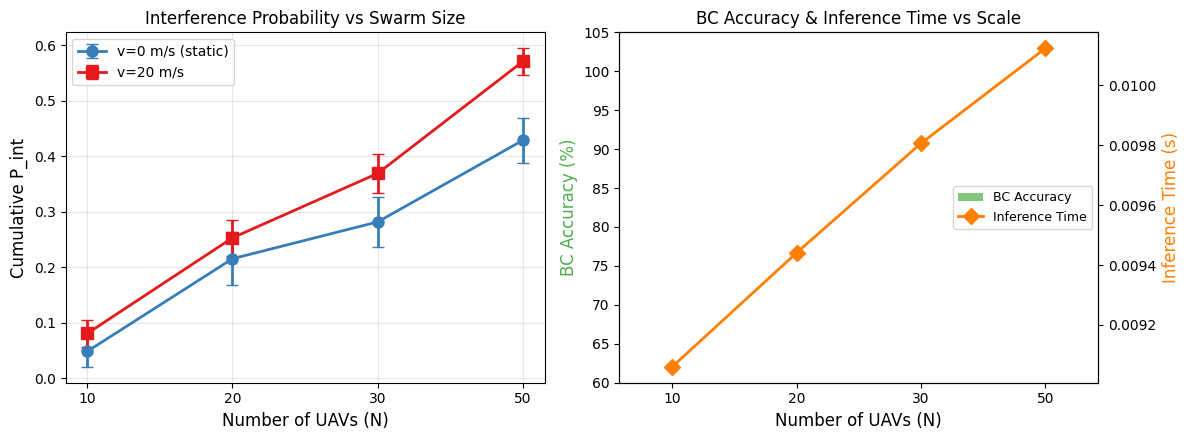

In [4]:
# 收集各规模BC动态结果
sizes = [10, 20, 30, 50]
bc_results = {}
for n in sizes:
    data = load_json(f'{DATA_DIR}/dynamic_bc_bc_orthogonal_N{n}.json')
    bc_results[n] = {
        'speed_0': gs(data, 0, 'cum_interf_prob_mean'),
        'speed_0_std': gs(data, 0, 'cum_interf_prob_std'),
        'speed_20': gs(data, 20, 'cum_interf_prob_mean'),
        'speed_20_std': gs(data, 20, 'cum_interf_prob_std'),
        'time_0': gs(data, 0, 'avg_total_inference_time_s'),
    }

# 收集训练accuracy
bc_accs = {}
for n in sizes:
    stats = load_json(f'{DATA_DIR}/bc_orthogonal_N{n}_stats.json')
    bc_accs[n] = stats['acc'][-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 左图: P_int vs N
x = np.arange(len(sizes))
p0 = [bc_results[n]['speed_0'] for n in sizes]
p0_std = [bc_results[n]['speed_0_std'] for n in sizes]
p20 = [bc_results[n]['speed_20'] for n in sizes]
p20_std = [bc_results[n]['speed_20_std'] for n in sizes]

ax1.errorbar(x, p0, yerr=p0_std, marker='o', linewidth=2, markersize=8, capsize=4, 
             color='#377eb8', label='v=0 m/s (static)')
ax1.errorbar(x, p20, yerr=p20_std, marker='s', linewidth=2, markersize=8, capsize=4,
             color='#e41a1c', label='v=20 m/s')
ax1.set_xlabel('Number of UAVs (N)', fontsize=12)
ax1.set_ylabel('Cumulative P_int', fontsize=12)
ax1.set_title('Interference Probability vs Swarm Size', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([str(n) for n in sizes])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 右图: Accuracy & Inference Time
accs = [bc_accs[n] for n in sizes]
times = [bc_results[n]['time_0'] for n in sizes]

ax2b = ax2.twinx()
bars = ax2.bar(x, accs, 0.5, color='#4daf4a', alpha=0.7, label='BC Accuracy')
line = ax2b.plot(x, times, marker='D', color='#ff7f00', linewidth=2, markersize=8, label='Inference Time')

ax2.set_xlabel('Number of UAVs (N)', fontsize=12)
ax2.set_ylabel('BC Accuracy (%)', fontsize=12, color='#4daf4a')
ax2b.set_ylabel('Inference Time (s)', fontsize=12, color='#ff7f00')
ax2.set_title('BC Accuracy & Inference Time vs Scale', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in sizes])
ax2.set_ylim(60, 105)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')

plt.tight_layout()
plt.show()


## Fig.4: BC训练曲线

展示N=10/20/30/50的BC训练过程中的accuracy和eval P_int变化。

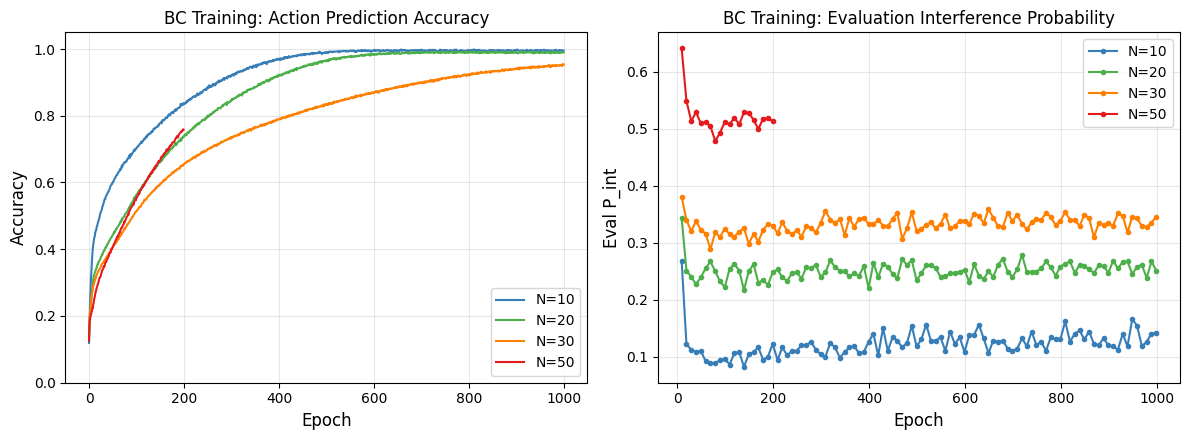

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
colors_n = {10: '#377eb8', 20: '#4daf4a', 30: '#ff7f00', 50: '#e41a1c'}

for n in sizes:
    stats = load_json(f'{DATA_DIR}/bc_orthogonal_N{n}_stats.json')
    epochs = stats['epoch']
    accs = stats['acc']
    evals = stats.get('eval_interf_probs', [])
    
    ax1.plot(epochs, accs, linewidth=1.5, color=colors_n[n], label=f'N={n}')
    
    # eval P_int (每eval_interval个epoch一次)
    eval_interval = 10
    eval_epochs = [e for i, e in enumerate(range(eval_interval-1, len(epochs), eval_interval)) if i < len(evals)]
    if eval_epochs:
        ax2.plot(eval_epochs, evals[:len(eval_epochs)], linewidth=1.5, marker='o', markersize=3, 
                color=colors_n[n], label=f'N={n}')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('BC Training: Action Prediction Accuracy', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Eval P_int', fontsize=12)
ax2.set_title('BC Training: Evaluation Interference Probability', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Fig.5: 消融实验

对比4种观测设计的BC accuracy和P_int。

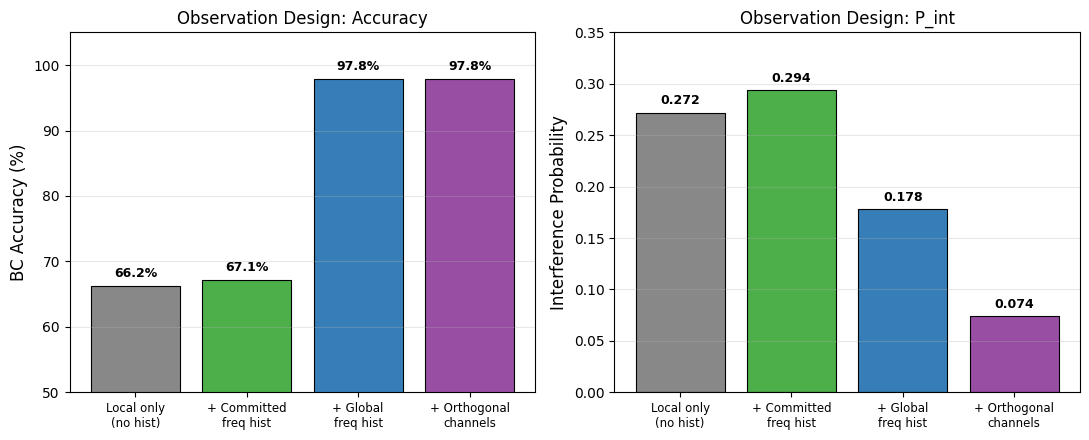

In [6]:
# 消融数据（从之前的实验记录中整理）
ablation_data = {
    'Local only\n(no hist)': {'obs_dim': 58, 'acc': 66.2, 'p_int': 0.272, 'n_freq': 20},
    '+ Committed\nfreq hist': {'obs_dim': 78, 'acc': 67.1, 'p_int': 0.294, 'n_freq': 20},
    '+ Global\nfreq hist': {'obs_dim': 98, 'acc': 97.8, 'p_int': 0.178, 'n_freq': 20},
    '+ Orthogonal\nchannels': {'obs_dim': 78, 'acc': 97.8, 'p_int': 0.074, 'n_freq': 10},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
labels = list(ablation_data.keys())
accs = [ablation_data[k]['acc'] for k in labels]
probs = [ablation_data[k]['p_int'] for k in labels]
colors_ab = ['#888888', '#4daf4a', '#377eb8', '#984ea3']

bars1 = ax1.bar(range(len(labels)), accs, color=colors_ab, edgecolor='black', linewidth=0.8)
ax1.set_ylabel('BC Accuracy (%)', fontsize=12)
ax1.set_title('Observation Design: Accuracy', fontsize=12)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=8.5)
ax1.set_ylim(50, 105)
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = ax2.bar(range(len(labels)), probs, color=colors_ab, edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Interference Probability', fontsize=12)
ax2.set_title('Observation Design: P_int', fontsize=12)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=8.5)
ax2.set_ylim(0, 0.35)
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, probs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## Fig.6: Zero-shot 跨规模泛化

用N=10训练的模型直接部署到N=20/30/50的结果。

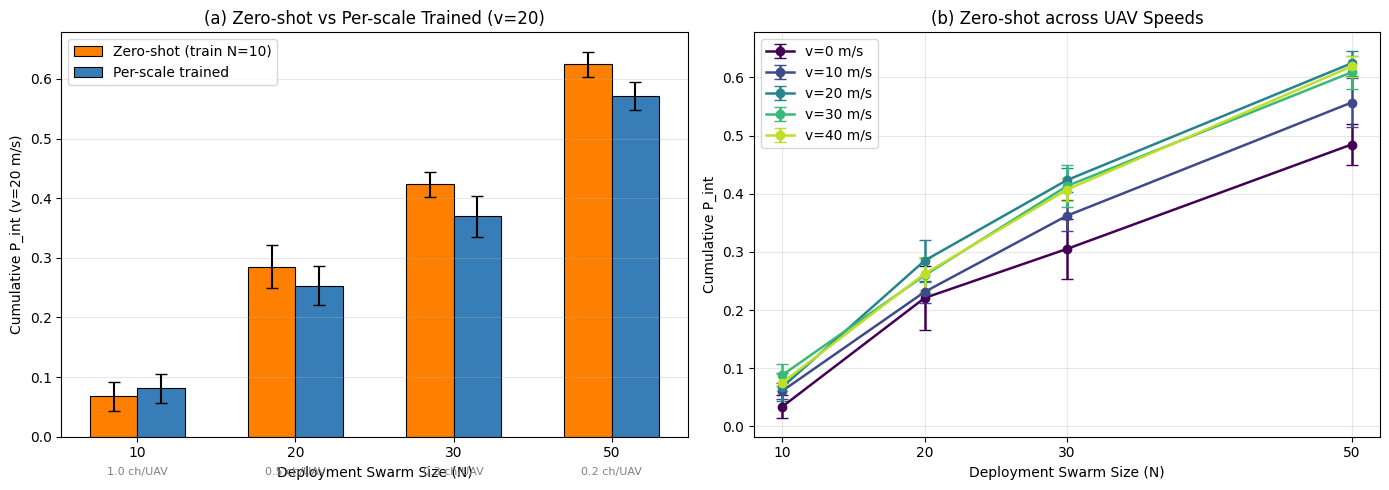

In [7]:
zs = load_json(f'{DATA_DIR}/zeroshot_N10_deploy_speed20.json')
deploy_sizes = [10, 20, 30, 50]
speeds = [0, 10, 20, 30, 40]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) speed=20 对比: zero-shot vs per-scale trained
zs_probs = [zs['results'][f'N{n}']['cum_interf_prob'] for n in deploy_sizes]
zs_stds = [zs['results'][f'N{n}']['std'] for n in deploy_sizes]
trained_probs = [bc_results[n]['speed_20'] for n in deploy_sizes]
trained_stds = [bc_results[n]['speed_20_std'] for n in deploy_sizes]
x = np.arange(len(deploy_sizes)); w = 0.3
axes[0].bar(x - w/2, zs_probs, w, yerr=zs_stds, capsize=4, color='#ff7f00',
           edgecolor='black', linewidth=0.8, label='Zero-shot (train N=10)')
axes[0].bar(x + w/2, trained_probs, w, yerr=trained_stds, capsize=4, color='#377eb8',
           edgecolor='black', linewidth=0.8, label='Per-scale trained')
axes[0].set_xticks(x); axes[0].set_xticklabels([str(n) for n in deploy_sizes])
axes[0].set_xlabel('Deployment Swarm Size (N)')
axes[0].set_ylabel('Cumulative P_int (v=20 m/s)')
axes[0].set_title('(a) Zero-shot vs Per-scale Trained (v=20)', fontsize=12)
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)
for i, n in enumerate(deploy_sizes):
    axes[0].text(i, -0.05, f'{10/n:.1f} ch/UAV', ha='center', va='top', fontsize=8, color='gray')

# (b) 多速度 zero-shot 折线: 一个 N=10 模型直接部署到各规模/各速度
colors = plt.cm.viridis(np.linspace(0, 0.9, len(speeds)))
for si, speed in enumerate(speeds):
    zs_s = load_json(f'{DATA_DIR}/zeroshot_N10_deploy_speed{speed}.json')
    probs = [zs_s['results'][f'N{n}']['cum_interf_prob'] for n in deploy_sizes]
    stds = [zs_s['results'][f'N{n}']['std'] for n in deploy_sizes]
    axes[1].errorbar(deploy_sizes, probs, yerr=stds, marker='o', capsize=4,
                     color=colors[si], label=f'v={speed} m/s', linewidth=1.8)
axes[1].set_xlabel('Deployment Swarm Size (N)')
axes[1].set_ylabel('Cumulative P_int')
axes[1].set_title('(b) Zero-shot across UAV Speeds', fontsize=12)
axes[1].set_xticks(deploy_sizes); axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Fig.7: 失败分析

左图: 干扰源距离分布
右图: 干扰源频率差分布

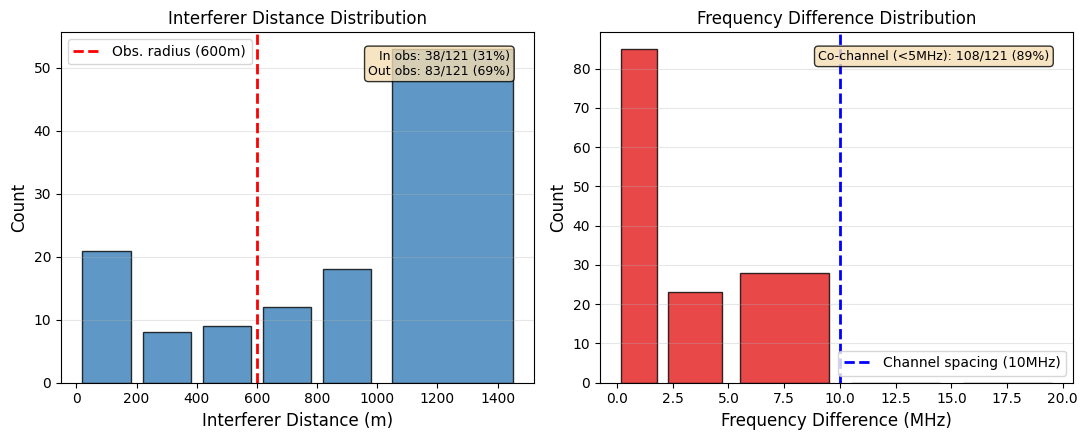

In [8]:
# 使用统计数据直接画图（failure_analysis.json被截断）
# 从之前的分析中提取的手动数据
distances_bins = [0, 200, 400, 600, 800, 1000, 1500]
distances_counts = [21, 8, 9, 12, 18, 53]  # 各区间的干扰对数量
freq_diff_bins = [0, 2, 5, 10, 15, 20]
freq_diff_counts = [85, 23, 28, 0, 0]  # 各区间的频率差对数量
total_pairs = sum(distances_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 左图: 距离分布
bar_centers = [(distances_bins[i]+distances_bins[i+1])/2 for i in range(len(distances_counts))]
bar_widths = [distances_bins[i+1]-distances_bins[i] for i in range(len(distances_counts))]
ax1.bar(bar_centers, distances_counts, width=[w*0.8 for w in bar_widths], color='#377eb8', edgecolor='black', alpha=0.8)
ax1.axvline(x=600, color='red', linestyle='--', linewidth=2, label='Obs. radius (600m)')
ax1.set_xlabel('Interferer Distance (m)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Interferer Distance Distribution', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

in_obs = sum(distances_counts[:3])  # <600m
out_obs = sum(distances_counts[3:])  # >=600m
ax1.text(0.95, 0.95, f'In obs: {in_obs}/{total_pairs} ({100*in_obs/total_pairs:.0f}%)\nOut obs: {out_obs}/{total_pairs} ({100*out_obs/total_pairs:.0f}%)',
        transform=ax1.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 右图: 频率差分布
bar_centers_f = [(freq_diff_bins[i]+freq_diff_bins[i+1])/2 for i in range(len(freq_diff_counts))]
bar_widths_f = [freq_diff_bins[i+1]-freq_diff_bins[i] for i in range(len(freq_diff_counts))]
ax2.bar(bar_centers_f, freq_diff_counts, width=[w*0.8 for w in bar_widths_f], color='#e41a1c', edgecolor='black', alpha=0.8)
ax2.axvline(x=10, color='blue', linestyle='--', linewidth=2, label='Channel spacing (10MHz)')
ax2.set_xlabel('Frequency Difference (MHz)', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Frequency Difference Distribution', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

co_channel = sum(freq_diff_counts[:2])  # <5MHz
ax2.text(0.95, 0.95, f'Co-channel (<5MHz): {co_channel}/{total_pairs} ({100*co_channel/total_pairs:.0f}%)',
        transform=ax2.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()


## 总结

所有图表已生成并保存至 `paper/figures/` 目录：

| 图号 | 文件名 | 内容 |
|------|--------|------|
| Fig.1 | fig1_dynamic_comparison | 动态场景方法对比柱状图 |
| Fig.2 | fig2_tradeoff | 性能-计算权衡散点图 |
| Fig.3 | fig3_scale | 规模扩展（P_int + accuracy/time） |
| Fig.4 | fig4_training | BC训练曲线 |
| Fig.5 | fig5_ablation | 消融实验 |
| Fig.6 | fig6_zeroshot | Zero-shot泛化 |
| Fig.7 | fig7_failure_analysis | 失败分析 |